In [6]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator

# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

In [7]:
from src.dataloading import BaseLineDataLoaderManager, DeepDataLoaderManager

n_epochs        = 500
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

baselinedataloader  = BaseLineDataLoaderManager(data_orchestrator)
deepdataloader      = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()


==                     lstm                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 3, 1), y=(400, 1))
Epoch 001 train loss: 0.7905, val loss: 1.0332 ✓ (new best)
Epoch 002 train loss: 0.6106, val loss: 0.8592 ✓ (new best)
Epoch 003 train loss: 0.5690, val loss: 0.8117 ✓ (new best)
Epoch 004 train loss: 0.5531, val loss: 0.7666 ✓ (new best)
Epoch 005 train loss: 0.5422, val loss: 0.7088 ✓ (new best)
Epoch 006 train loss: 0.5293, val loss: 0.6698 ✓ (new best)
Epoch 007 train loss: 0.5145, val loss: 0.6070 ✓ (new best)
Epoch 008 train loss: 0.5191, val loss: 0.6251 (patience: 1/20)
Epoch 009 train loss: 0.4923, val loss: 0.5379 ✓ (new best)
Epoch 010 train loss: 0.4885, val loss: 0.5430 (patience: 1/20)
Epoch 011 train loss: 0.4757, val loss: 0.4645 ✓ (new best)
Epoch 012 train loss: 0.4766, val loss: 0.4872 (patience: 1/20)
Epoch 013 train loss: 0.4571, val loss: 0.4344 ✓ (new best)
Epoch 014 train loss: 0.4568, val loss: 0.4441 (patience: 

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:247: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 365.20it/s]


Test loss: 0.5897
forecasted ✓

==                     gru                      ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 3, 1), y=(400, 1))
Epoch 001 train loss: 0.7075, val loss: 0.8863 ✓ (new best)
Epoch 002 train loss: 0.5637, val loss: 0.8186 ✓ (new best)
Epoch 003 train loss: 0.5341, val loss: 0.7723 ✓ (new best)
Epoch 004 train loss: 0.5155, val loss: 0.7311 ✓ (new best)
Epoch 005 train loss: 0.4968, val loss: 0.6894 ✓ (new best)
Epoch 006 train loss: 0.4794, val loss: 0.6505 ✓ (new best)
Epoch 007 train loss: 0.4632, val loss: 0.6199 ✓ (new best)
Epoch 008 train loss: 0.4541, val loss: 0.5953 ✓ (new best)
Epoch 009 train loss: 0.4440, val loss: 0.5748 ✓ (new best)
Epoch 010 train loss: 0.4388, val loss: 0.5568 ✓ (new best)
Epoch 011 train loss: 0.4353, val loss: 0.5357 ✓ (new best)
Epoch 012 train loss: 0.4286, val loss: 0.5199 ✓ (new best)
Epoch 013 train loss: 0.4262, val loss: 0.4998 ✓ (new best)
Epoch 014 train loss: 0.4262, val loss:

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:247: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3414
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 602.12it/s]


Test loss: 0.5752
forecasted ✓


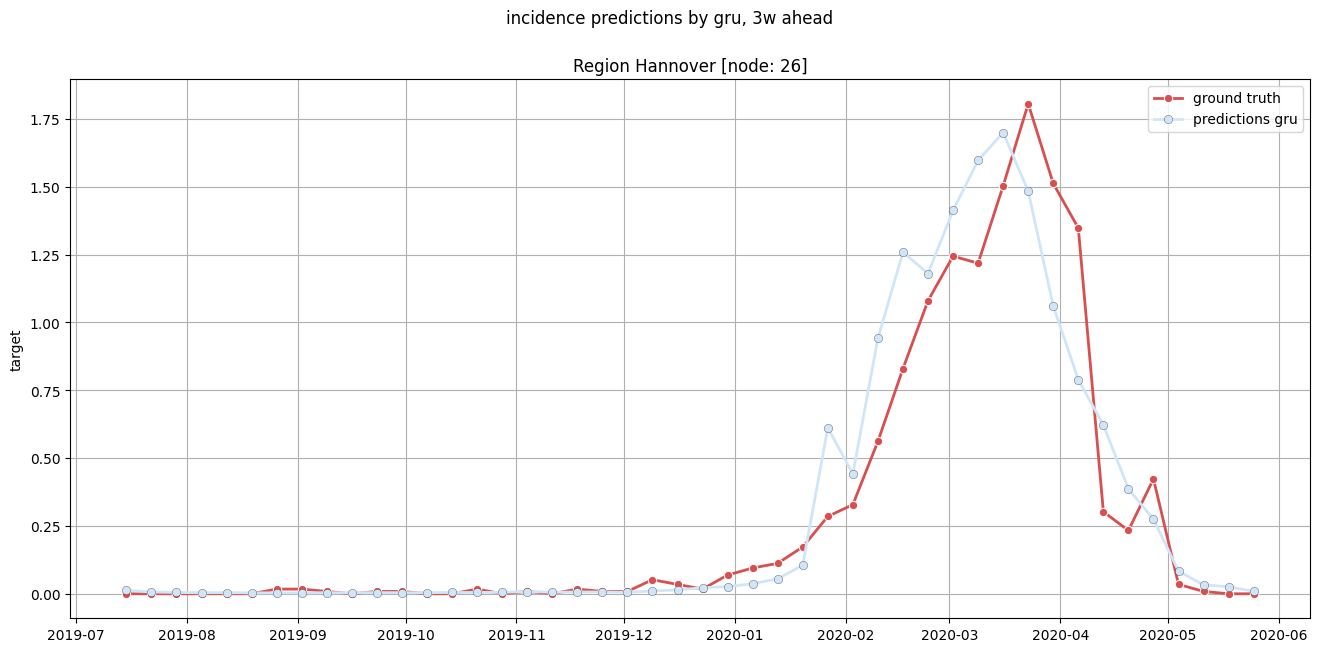

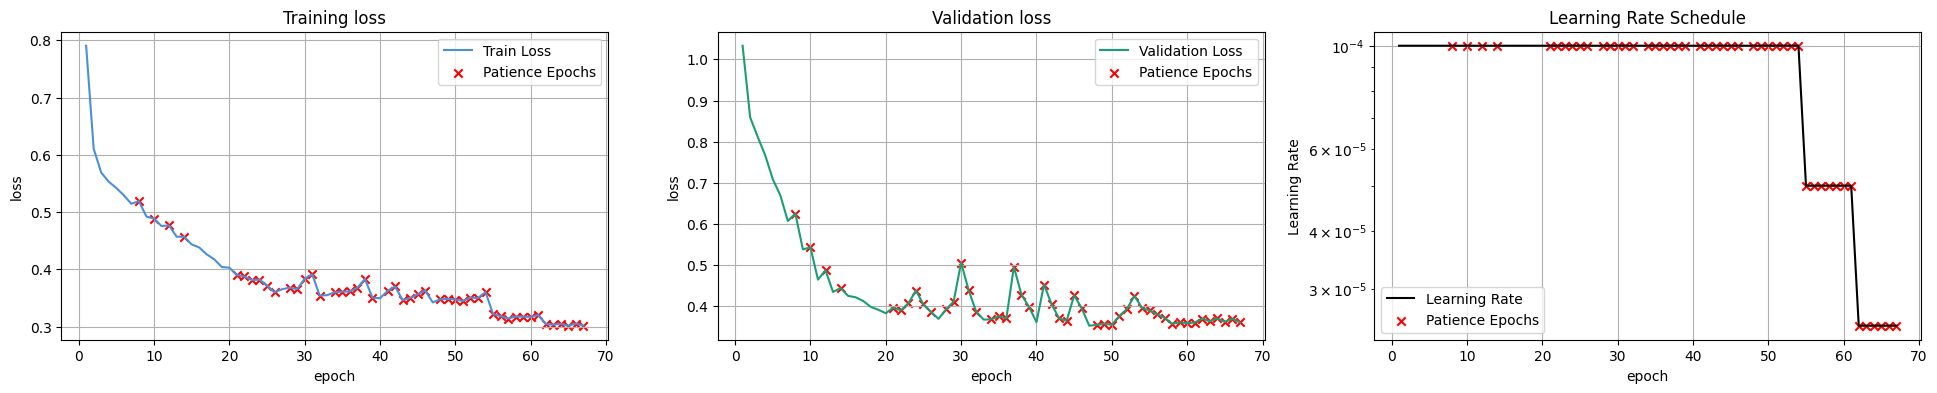

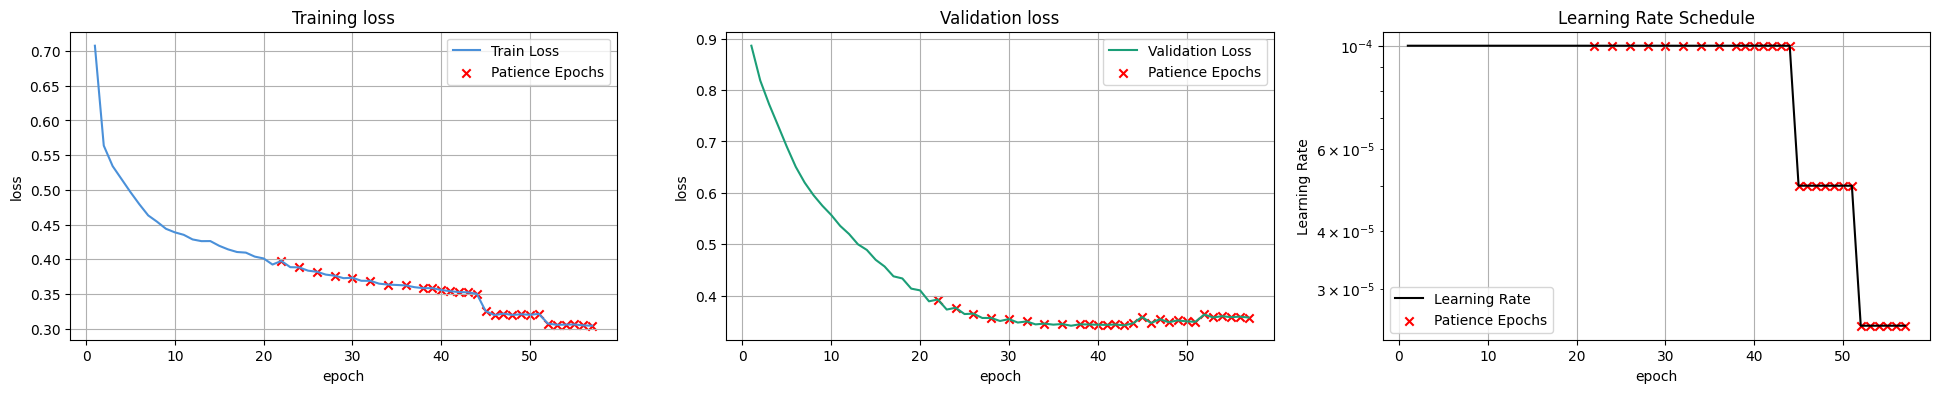

In [8]:
from src.models import NodeLSTMModel, NodeGRUModel

lstm = NodeLSTMModel(deepdataloader, name = 'lstm', verbose = 2)
lstm.set_model_hparams(hidden_size=128)
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')
lstm.show_forecasts(26)

gru = NodeGRUModel(deepdataloader, name = 'gru', verbose = 2)
gru.set_model_hparams(hidden_size=128)
gru.set_global_hparams(**global_hparams)
gru.train()
gru.forecast('test')
gru.show_forecasts(26).show()

In [9]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedataloader)
persistence.forecast()

climateology = ClimateologyModel(baselinedataloader)
climateology.forecast()

climascale = ClimaScaleModel(baselinedataloader)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]

computing metrics: 100%|████████████████████████████████████████████████████████████████████████| 6/6 [00:08<00:00,  1.45s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels

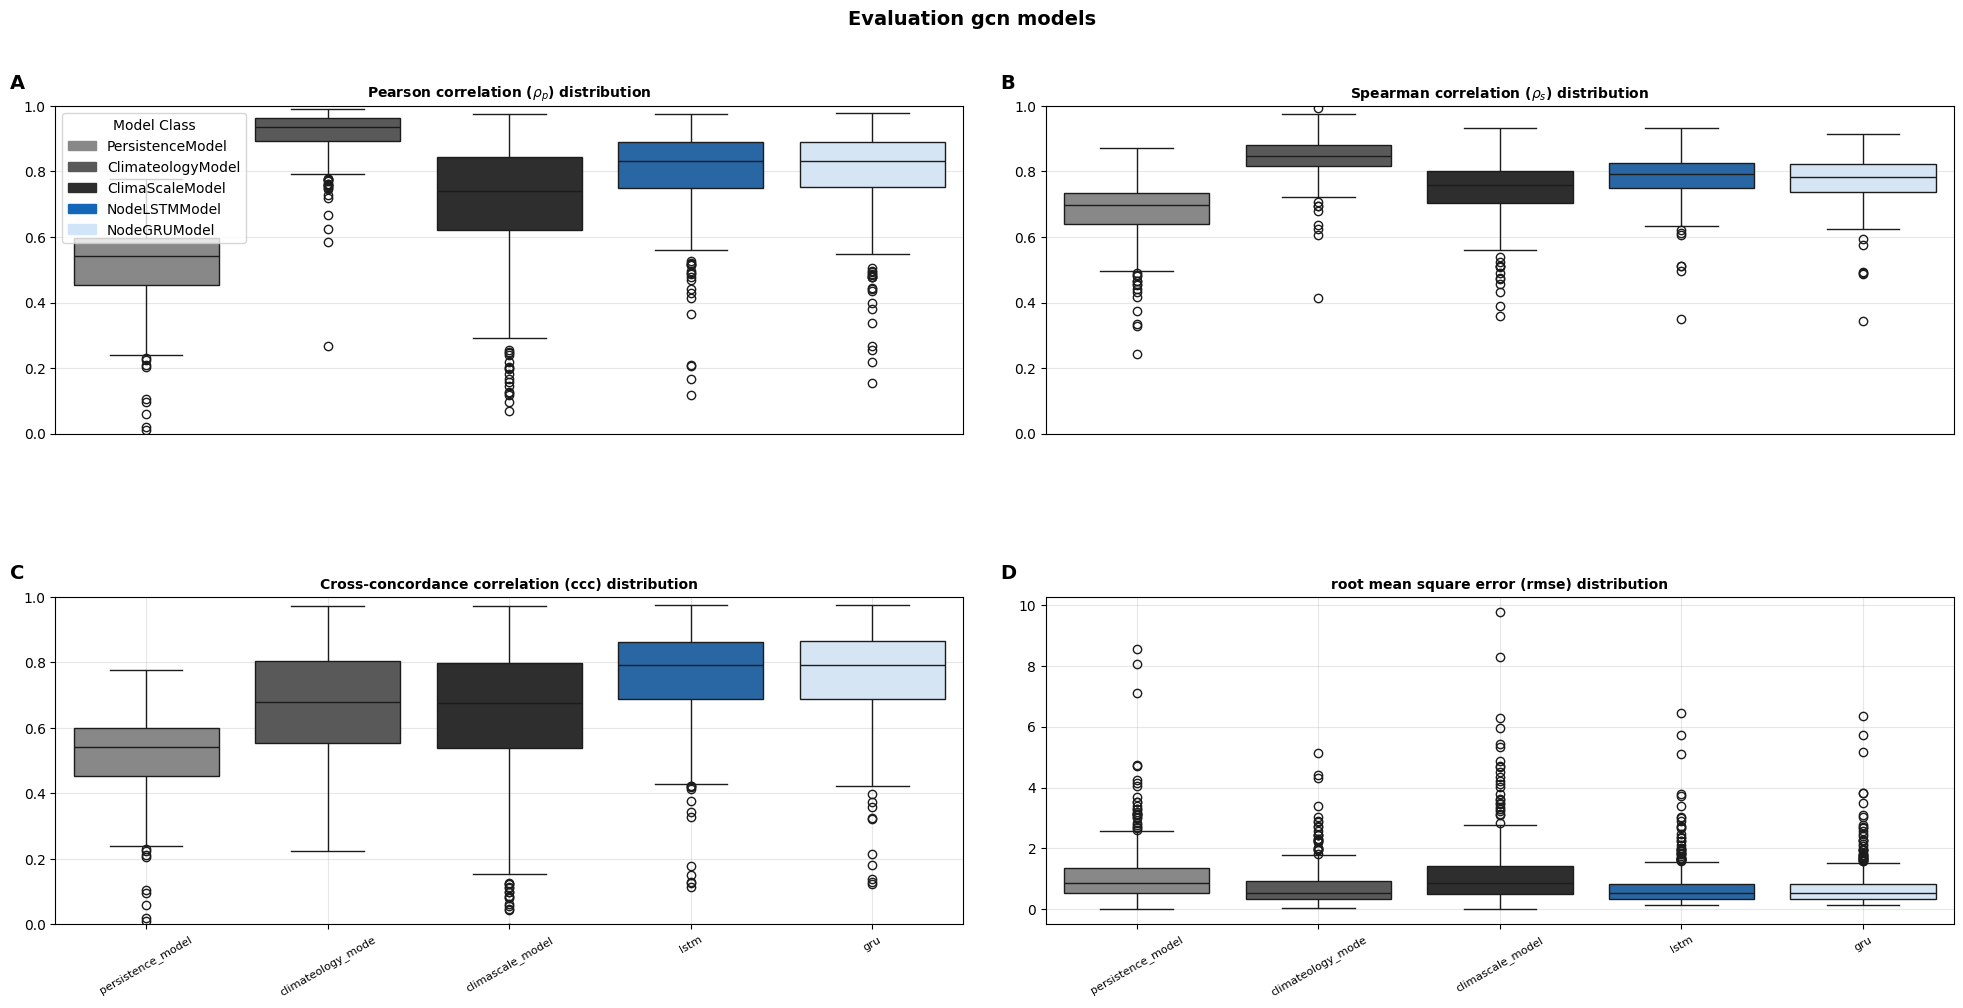

In [10]:
evaluation_experiment_sgnn = Evaluator(baseline_models + [lstm,gru]).add_evaluation()
f_merged_raw    = evaluation_experiment_sgnn.plotter.plot_metric_compilation(subfig_size = (8,4), plot_types = ['box','box','box','box']);

f_merged = (f_merged_raw
    .labels.change_suptitle(suptitle='Evaluation gcn models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 0)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 1)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 2)    
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)   
    .layout.set_ylim([0,1],ax = 0)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)        
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,10)       
    )
f_merged.show()